<a href="https://colab.research.google.com/github/adrian-ai-salud/Resultados-estudio-/blob/main/Perception%2C_Acceptance%2C_and_Readiness_Regarding_Artificial_Intelligence_Among_Primary_Care_Nurses.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install --quiet pandas numpy scipy statsmodels scikit-learn factor_analyzer pingouin openpyxl spacy matplotlib seaborn
!python -m spacy download es_core_news_sm --quiet
print('✅ Dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 1.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 76.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ Dependencies installed.


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
from statsmodels.stats.diagnostic import linear_reset
from statsmodels.discrete.discrete_model import Logit
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from factor_analyzer import FactorAnalyzer
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
import pingouin as pg
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
np.random.seed(42)

print('✅ Imports complete.')
print(f'   pandas {pd.__version__}, numpy {np.__version__}')
print(f'   scipy {stats.__version__ if hasattr(stats, "__version__") else "loaded"}')
print(f'   statsmodels {sm.__version__}')

✅ Imports complete.
   pandas 2.2.2, numpy 2.0.2
   scipy loaded
   statsmodels 0.14.6


## 2. Data loading

Upload the SHAIP survey Excel file when prompted. The expected structure is 102 rows × 26 columns including timestamp, consent, sociodemographic variables, training variables, the 10 SHAIP Likert items, and 2 open-ended questions.

In [ ]:
from google.colab import files
print('Please upload the SHAIP survey Excel file (.xlsx)')
uploaded = files.upload()
file_name = list(uploaded.keys())[0]
df_raw = pd.read_excel(file_name)
print(f'\n✅ Dataset loaded: {file_name}')
print(f'   Shape: {df_raw.shape[0]} rows × {df_raw.shape[1]} columns')

# Validate expected structure
assert df_raw.shape[0] == 102, f'Expected 102 rows, got {df_raw.shape[0]}'
assert df_raw.shape[1] >= 24, f'Expected at least 24 columns, got {df_raw.shape[1]}'
print('   Structural validation: PASSED')

Please upload the SHAIP survey Excel file (.xlsx)


Saving Estudio UNIR (respuestas).xlsx to Estudio UNIR (respuestas).xlsx

✅ Dataset loaded: Estudio UNIR (respuestas).xlsx
   Shape: 102 rows × 26 columns
   Structural validation: PASSED


## 3. Data preprocessing

This section standardizes column names, parses age (handling text edge cases like "61 anos"), categorizes age groups, maps Galician Likert responses to numeric values (1–5), computes construct scores, and creates the binary variables used in modeling.

**Key analytical decision:** "Non sei" (don't know) responses to AI clinical use are treated as non-users, consistent with a conservative approach that does not assume AI usage in cases of uncertainty.

In [ ]:
col_names = [
    'timestamp', 'consent', 'age_raw', 'sex', 'experience', 'education',
    'health_area', 'setting', 'tech_freq', 'ai_understanding',
    'ai_clinical_use', 'ai_training_received', 'wants_training',
    'training_importance',
    'item1', 'item2', 'item3', 'item4', 'item5', 'item6',
    'item7', 'item8', 'item9', 'item10',
    'barriers_open', 'training_areas_open'
]
df = df_raw.copy()
df.columns = col_names[:df.shape[1]]

# Parse age robustly
def parse_age(value):
    if pd.isna(value):
        return np.nan
    s = str(value).lower().replace('anos', '').replace('años', '').strip()
    try:
        return float(s)
    except ValueError:
        match = re.search(r'\d+', s)
        return float(match.group()) if match else np.nan

df['age'] = df['age_raw'].apply(parse_age)

# Categorize age
def age_cat(x):
    if pd.isna(x): return np.nan
    if x <= 35: return '≤35 years'
    elif x <= 50: return '36–50 years'
    else: return '>50 years'
df['age_group'] = df['age'].apply(age_cat)

# Map Likert (Galician) to numeric
likert_map = {
    'Totalmente de acordo': 5,
    'De acordo': 4,
    'Nin de acordo nin en desacordo': 3,
    'En desacordo': 2,
    'Totalemnte en desacordo': 1,
    'Totalmente en desacordo': 1,
}
for i in range(1, 11):
    df[f'item{i}'] = df[f'item{i}'].map(likert_map)

# Construct scores
impact_items = [f'item{i}' for i in range(1, 7)]
readiness_items = [f'item{i}' for i in range(7, 11)]
df['impact_score'] = df[impact_items].mean(axis=1)
df['readiness_score'] = df[readiness_items].mean(axis=1)

# Binary variables for modeling
df['ai_user'] = (df['ai_clinical_use'].astype(str).str.strip() == 'Sí').astype(int)
df['has_training'] = (~df['ai_training_received'].astype(str).str.strip().isin(['Ningunha', 'nan'])).astype(int)
df['postgraduate'] = df['education'].isin(['Máster', 'Doutorado']).astype(int)
df['urban'] = (df['setting'] == 'Urbano').astype(int)

print('✅ Preprocessing complete')
print(f'   Final n = {len(df)}')
print(f'   AI users: {df["ai_user"].sum()} ({df["ai_user"].mean()*100:.1f}%)')
print(f'   With prior training: {df["has_training"].sum()} ({df["has_training"].mean()*100:.1f}%)')
print(f'   Missing values per modeling variable:')
for col in ['age', 'ai_user', 'has_training', 'urban', 'postgraduate']:
    print(f'      {col}: {df[col].isna().sum()}')

✅ Preprocessing complete
   Final n = 102
   AI users: 20 (19.6%)
   With prior training: 31 (30.4%)
   Missing values per modeling variable:
      age: 0
      ai_user: 0
      has_training: 0
      urban: 0
      postgraduate: 0


## 4. Descriptive analysis (Table 1)

### Assumption check for continuous variables

For age, normality is tested using **Shapiro-Wilk** (more powerful than Kolmogorov-Smirnov for n<5000) and visualized with a Q-Q plot. The decision to report mean±SD vs median[IQR] follows the result.

TABLE 1 — Descriptive analysis with assumption checks

📋 ASSUMPTION CHECK: Normality of age
   Shapiro-Wilk: W = 0.9358, p = 0.0001
   Kolmogorov-Smirnov (Lilliefors-corrected interpretation): D = 0.1262, p = 0.0710
   ⚠️ Normality assumption violated — also reporting median [IQR]


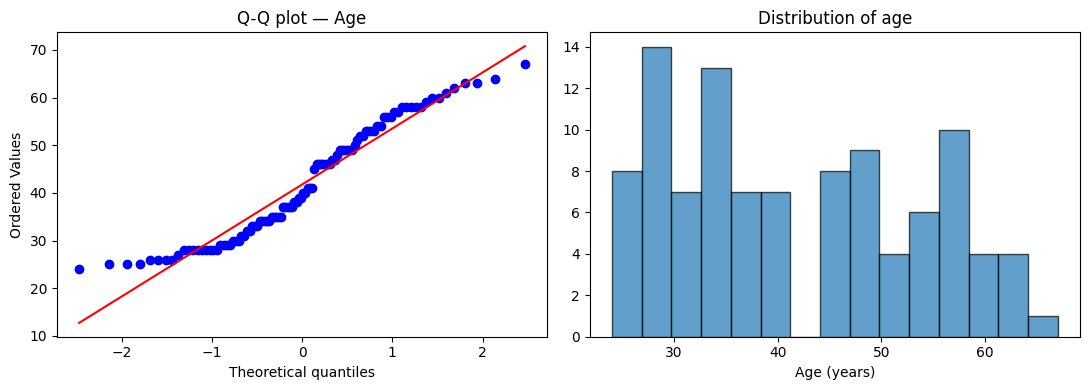


   Age — Mean: 41.75, SD: 11.93
   95% CI for the mean: [39.41, 44.10]
   Range: 24–67 years

📋 Categorical variables — frequencies and percentages

--- Age group ---
   ≤35 years: 42 (41.2%)
   36–50 years: 32 (31.4%)
   >50 years: 28 (27.5%)

--- Sex ---
   Muller: 84 (82.4%)
   Home: 18 (17.6%)

--- Experience ---
   >10 anos: 64 (62.7%)
   6-10 anos: 20 (19.6%)
   1-5 anos: 18 (17.6%)

--- Education ---
   Grado: 68 (66.7%)
   Máster: 32 (31.4%)
   Doutorado: 2 (2.0%)

--- Health area ---
   Santiago-Barbanza: 81 (79.4%)
   Ourense-Verín-O Barco: 6 (5.9%)
   Vigo: 5 (4.9%)
   A Coruña-Cee: 3 (2.9%)
   Pontevedra-Salnés: 3 (2.9%)
   Lugo-A Mariña-Monforte: 2 (2.0%)
   Ferrol: 2 (2.0%)

--- Setting ---
   Urbano: 51 (50.0%)
   Rural: 51 (50.0%)

--- Tech frequency ---
   Frecuentemente: 32 (31.4%)
   Sempre: 27 (26.5%)
   Ás veces: 26 (25.5%)
   Raramente: 11 (10.8%)
   Nunca: 6 (5.9%)

--- AI understanding ---
   Bastante: 41 (40.2%)
   Algo: 41 (40.2%)
   Pouco: 15 (14.7%)
   Tota

In [ ]:
print('='*70)
print('TABLE 1 — Descriptive analysis with assumption checks')
print('='*70)

# --- Normality of age ---
print('\n📋 ASSUMPTION CHECK: Normality of age')
shapiro_stat, shapiro_p = stats.shapiro(df['age'].dropna())
print(f'   Shapiro-Wilk: W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}')
ks_stat, ks_p = stats.kstest(df['age'].dropna(), 'norm',
                              args=(df['age'].mean(), df['age'].std()))
print(f'   Kolmogorov-Smirnov (Lilliefors-corrected interpretation): D = {ks_stat:.4f}, p = {ks_p:.4f}')

if shapiro_p > 0.05:
    print('   ✅ Normality assumption met — reporting mean ± SD')
    age_summary = f'{df["age"].mean():.2f} ± {df["age"].std():.2f}'
else:
    print('   ⚠️ Normality assumption violated — also reporting median [IQR]')
    age_summary = f'mean {df["age"].mean():.2f} ± {df["age"].std():.2f}; median {df["age"].median():.1f} [IQR {df["age"].quantile(0.25):.1f}–{df["age"].quantile(0.75):.1f}]'

# Q-Q plot
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
stats.probplot(df['age'].dropna(), dist='norm', plot=ax[0])
ax[0].set_title('Q-Q plot — Age')
ax[1].hist(df['age'].dropna(), bins=15, edgecolor='black', alpha=0.7)
ax[1].set_title('Distribution of age')
ax[1].set_xlabel('Age (years)')
plt.tight_layout()
plt.savefig('age_normality.png', dpi=300, bbox_inches='tight')
plt.show()

# 95% CI for age
age_clean = df['age'].dropna()
ci_low, ci_high = stats.t.interval(0.95, len(age_clean)-1,
                                    age_clean.mean(), stats.sem(age_clean))
print(f'\n   Age — Mean: {age_clean.mean():.2f}, SD: {age_clean.std():.2f}')
print(f'   95% CI for the mean: [{ci_low:.2f}, {ci_high:.2f}]')
print(f'   Range: {age_clean.min():.0f}–{age_clean.max():.0f} years')

# --- Categorical descriptives ---
print('\n📋 Categorical variables — frequencies and percentages')
categorical = {
    'Age group': 'age_group', 'Sex': 'sex', 'Experience': 'experience',
    'Education': 'education', 'Health area': 'health_area', 'Setting': 'setting',
    'Tech frequency': 'tech_freq', 'AI understanding': 'ai_understanding',
    'AI clinical use': 'ai_clinical_use', 'Prior training': 'ai_training_received',
    'Wants training': 'wants_training', 'Importance': 'training_importance',
}
for label, col in categorical.items():
    print(f'\n--- {label} ---')
    counts = df[col].value_counts(dropna=False)
    pcts = df[col].value_counts(normalize=True, dropna=False) * 100
    for cat in counts.index:
        print(f'   {cat}: {counts[cat]} ({pcts[cat]:.1f}%)')

## 5. SHAIP scores (Table 2)

Mean, standard deviation, and 95% confidence intervals for each item and construct. Confidence intervals use Student's t distribution (appropriate for n=102 with finite-sample correction).

In [ ]:
print('='*70)
print('TABLE 2 — SHAIP item-level and construct-level descriptives')
print('='*70)

def describe_item(series, label):
    s = series.dropna()
    n = len(s)
    mean, sd = s.mean(), s.std()
    sem = stats.sem(s)
    ci = stats.t.interval(0.95, n-1, mean, sem)
    return {'Item': label, 'n': n, 'Mean': round(mean, 2),
            'SD': round(sd, 2), '95% CI': f'[{ci[0]:.2f}, {ci[1]:.2f}]'}

results = [describe_item(df['impact_score'], 'Professional Impact (construct)')]
for i in range(1, 7):
    results.append(describe_item(df[f'item{i}'], f'Item {i}'))
results.append(describe_item(df['readiness_score'], 'Readiness (construct)'))
for i in range(7, 11):
    results.append(describe_item(df[f'item{i}'], f'Item {i}'))

table2_df = pd.DataFrame(results)
print(table2_df.to_string(index=False))

TABLE 2 — SHAIP item-level and construct-level descriptives
                           Item   n  Mean   SD       95% CI
Professional Impact (construct) 102  3.98 0.60 [3.87, 4.10]
                         Item 1 102  4.07 0.72 [3.93, 4.21]
                         Item 2 102  4.07 0.69 [3.93, 4.20]
                         Item 3 102  4.03 0.76 [3.88, 4.18]
                         Item 4 102  3.91 0.90 [3.73, 4.09]
                         Item 5 102  3.58 0.97 [3.39, 3.77]
                         Item 6 102  4.25 0.65 [4.12, 4.37]
          Readiness (construct) 102  2.60 0.66 [2.47, 2.73]
                         Item 7 102  2.48 1.01 [2.28, 2.68]
                         Item 8 102  1.75 1.01 [1.55, 1.94]
                         Item 9 102  2.76 1.20 [2.53, 3.00]
                        Item 10 102  3.41 1.16 [3.18, 3.64]


## 6. Psychometric analysis with full assumption checks (S1 Table)

### Assumptions verified before EFA:

1. **Sample adequacy** — Kaiser-Meyer-Olkin (KMO) ≥ 0.6 (≥0.8 meritorious)
2. **Sphericity** — Bartlett's test must be significant (p < 0.05)
3. **Determinant of correlation matrix** — must be > 0.00001 (rules out extreme multicollinearity)
4. **Sample size** — minimum subject:variable ratio of 5:1 (we have 10:1)

### Reliability:

- **Cronbach's alpha** with 95% CI for both constructs
- **Item-total correlations** (corrected) for each item
- **Alpha if item deleted** for each item — diagnostic for construct integrity
- **McDonald's omega** as a more robust alternative to alpha when tau-equivalence is violated

In [ ]:
print('='*70)
print('S1 TABLE — Psychometric analysis with assumption checks')
print('='*70)

items_df = df[[f'item{i}' for i in range(1, 11)]].dropna()

# --- ASSUMPTION 1: Sample adequacy (KMO) ---
print('\n📋 ASSUMPTION 1: Sample adequacy')
kmo_per_item, kmo_overall = calculate_kmo(items_df)
print(f'   KMO overall = {kmo_overall:.3f}')
if kmo_overall >= 0.8:
    print('   ✅ Meritorious sample adequacy (≥0.8)')
elif kmo_overall >= 0.6:
    print('   ✅ Acceptable sample adequacy (≥0.6)')
else:
    print('   ❌ Inadequate — EFA not recommended')
print('   KMO per item:')
for i, k in enumerate(kmo_per_item, 1):
    print(f'      Item {i}: {k:.3f}')

# --- ASSUMPTION 2: Sphericity (Bartlett) ---
print('\n📋 ASSUMPTION 2: Sphericity')
chi_sq, bartlett_p = calculate_bartlett_sphericity(items_df)
print(f"   Bartlett's test: χ² = {chi_sq:.2f}, p = {bartlett_p:.4g}")
if bartlett_p < 0.05:
    print('   ✅ Sphericity rejected — correlations are sufficient for EFA')
else:
    print('   ❌ Identity matrix not rejected — EFA inappropriate')

# --- ASSUMPTION 3: Determinant of correlation matrix ---
print('\n📋 ASSUMPTION 3: Determinant of correlation matrix')
corr_matrix = items_df.corr()
det = np.linalg.det(corr_matrix)
print(f'   Determinant = {det:.6f}')
if det > 0.00001:
    print('   ✅ No extreme multicollinearity (>0.00001)')
else:
    print('   ❌ Extreme multicollinearity detected')

# --- ASSUMPTION 4: Subject:variable ratio ---
print('\n📋 ASSUMPTION 4: Sample size adequacy')
ratio = len(items_df) / 10
print(f'   Subject:variable ratio = {ratio:.1f}:1')
if ratio >= 10:
    print('   ✅ Excellent (≥10:1)')
elif ratio >= 5:
    print('   ✅ Acceptable (≥5:1)')
else:
    print('   ❌ Insufficient')

# --- EFA: Principal axis factoring with varimax rotation ---
print('\n🔬 EXPLORATORY FACTOR ANALYSIS')
print('   Method: Principal axis factoring')
print('   Rotation: Varimax (orthogonal)')
print('   Number of factors: 2 (theory-driven)')

fa = FactorAnalyzer(n_factors=2, rotation='varimax', method='principal')
fa.fit(items_df)

loadings = pd.DataFrame(fa.loadings_,
                        index=[f'Item {i}' for i in range(1, 11)],
                        columns=['Factor 1 (Impact)', 'Factor 2 (Readiness)'])
print('\nFactor loadings:')
print(loadings.round(3))

ev, v, cumv = fa.get_factor_variance()
print(f'\nVariance explained:')
print(f'   Factor 1: {v[0]*100:.2f}%')
print(f'   Factor 2: {v[1]*100:.2f}%')
print(f'   Cumulative: {cumv[1]*100:.2f}%')

# Communalities
communalities = pd.Series(fa.get_communalities(),
                          index=[f'Item {i}' for i in range(1, 11)])
print('\nCommunalities (variance of each item explained by both factors):')
for item, c in communalities.items():
    flag = '✅' if c >= 0.4 else '⚠️'
    print(f'   {item}: {c:.3f} {flag}')

# --- RELIABILITY ---
print('\n🔬 RELIABILITY ANALYSIS')

# Cronbach's alpha + 95% CI
alpha_imp, ci_imp = pg.cronbach_alpha(data=df[impact_items].dropna(), ci=0.95)
alpha_rea, ci_rea = pg.cronbach_alpha(data=df[readiness_items].dropna(), ci=0.95)
print(f"\nCronbach's alpha:")
print(f'   Impact:    α = {alpha_imp:.3f}, 95% CI [{ci_imp[0]:.3f}, {ci_imp[1]:.3f}]')
print(f'   Readiness: α = {alpha_rea:.3f}, 95% CI [{ci_rea[0]:.3f}, {ci_rea[1]:.3f}]')

# Alpha if item deleted
def alpha_if_deleted(data):
    results = {}
    for col in data.columns:
        remaining = data.drop(columns=[col])
        a, _ = pg.cronbach_alpha(data=remaining, ci=0.95)
        results[col] = a
    return results

print('\nAlpha if item deleted (Impact construct):')
for item, a in alpha_if_deleted(df[impact_items].dropna()).items():
    flag = '⚠️' if a > alpha_imp else '  '
    print(f'   Without {item}: α = {a:.3f} {flag}')

print('\nAlpha if item deleted (Readiness construct):')
for item, a in alpha_if_deleted(df[readiness_items].dropna()).items():
    flag = '⚠️' if a > alpha_rea else '  '
    print(f'   Without {item}: α = {a:.3f} {flag}')

# Corrected item-total correlations
print('\nCorrected item-total correlations:')
for items, label in [(impact_items, 'Impact'), (readiness_items, 'Readiness')]:
    print(f'\n   {label}:')
    data = df[items].dropna()
    for item in items:
        rest = data.drop(columns=[item]).sum(axis=1)
        r = data[item].corr(rest)
        flag = '✅' if r >= 0.3 else '⚠️'
        print(f'      {item}: r = {r:.3f} {flag}')

S1 TABLE — Psychometric analysis with assumption checks

📋 ASSUMPTION 1: Sample adequacy
   KMO overall = 0.813
   ✅ Meritorious sample adequacy (≥0.8)
   KMO per item:
      Item 1: 0.831
      Item 2: 0.835
      Item 3: 0.814
      Item 4: 0.807
      Item 5: 0.915
      Item 6: 0.900
      Item 7: 0.702
      Item 8: 0.711
      Item 9: 0.691
      Item 10: 0.414

📋 ASSUMPTION 2: Sphericity
   Bartlett's test: χ² = 347.88, p = 2.032e-48
   ✅ Sphericity rejected — correlations are sufficient for EFA

📋 ASSUMPTION 3: Determinant of correlation matrix
   Determinant = 0.027529
   ✅ No extreme multicollinearity (>0.00001)

📋 ASSUMPTION 4: Sample size adequacy
   Subject:variable ratio = 10.2:1
   ✅ Excellent (≥10:1)

🔬 EXPLORATORY FACTOR ANALYSIS
   Method: Principal axis factoring
   Rotation: Varimax (orthogonal)
   Number of factors: 2 (theory-driven)

Factor loadings:
         Factor 1 (Impact)  Factor 2 (Readiness)
Item 1               0.760                 0.164
Item 2           

## 7. Bivariate analysis (S2 Table)

### Test selection logic

For each 2×2 contingency table, **expected cell frequencies** are checked. If any expected frequency < 5, **Fisher's exact test** is used; otherwise, **Pearson's chi-square** is applied.

The full sample (n=102) is used, with "Non sei" responses to AI clinical use treated as non-users.

In [ ]:
print('='*70)
print('S2 TABLE — AI users vs non-users with assumption checks')
print('='*70)

df_bi = df.copy()
print(f'\nUsers: {(df_bi["ai_user"]==1).sum()}, Non-users: {(df_bi["ai_user"]==0).sum()}')

def odds_ratio_2x2(table):
    a, b = table[0]
    c, d = table[1]
    if 0 in [a, b, c, d]:
        a, b, c, d = a+0.5, b+0.5, c+0.5, d+0.5
    or_val = (a*d) / (b*c)
    log_or = np.log(or_val)
    se = np.sqrt(1/a + 1/b + 1/c + 1/d)
    return or_val, np.exp(log_or - 1.96*se), np.exp(log_or + 1.96*se)

def bivar_with_assumptions(var, label):
    print(f'\n--- {label} ---')
    ct = pd.crosstab(df_bi[var], df_bi['ai_user'])
    print(ct)

    # Check expected frequencies
    chi2, p_chi, dof, expected = stats.chi2_contingency(ct.values)
    min_expected = expected.min()
    print(f'\n   Minimum expected frequency: {min_expected:.2f}')

    if min_expected < 5:
        print('   ⚠️ Expected frequency < 5 → using Fisher\'s exact test')
        if ct.shape == (2, 2):
            _, p = stats.fisher_exact(ct.values)
            or_v, ci_l, ci_h = odds_ratio_2x2(ct.values)
            print(f'   Fisher exact: OR = {or_v:.2f} (95% CI: {ci_l:.2f}–{ci_h:.2f}), p = {p:.3f}')
        else:
            print(f'   χ² = {chi2:.2f}, df = {dof}, p = {p_chi:.3f} (interpret with caution)')
    else:
        print('   ✅ All expected frequencies ≥ 5 → using Pearson\'s chi-square')
        if ct.shape == (2, 2):
            or_v, ci_l, ci_h = odds_ratio_2x2(ct.values)
            print(f'   χ² = {chi2:.2f}, df = {dof}, p = {p_chi:.3f}')
            print(f'   OR = {or_v:.2f} (95% CI: {ci_l:.2f}–{ci_h:.2f})')
        else:
            print(f'   χ² = {chi2:.2f}, df = {dof}, p = {p_chi:.3f}')

bivar_with_assumptions('sex', 'Sex')
bivar_with_assumptions('postgraduate', 'Educational level (Postgraduate vs Bachelor)')
bivar_with_assumptions('urban', 'Work setting (Urban vs Rural)')
bivar_with_assumptions('has_training', 'Prior AI training')

S2 TABLE — AI users vs non-users with assumption checks

Users: 20, Non-users: 82

--- Sex ---
ai_user   0   1
sex            
Home     14   4
Muller   68  16

   Minimum expected frequency: 3.53
   ⚠️ Expected frequency < 5 → using Fisher's exact test
   Fisher exact: OR = 0.82 (95% CI: 0.24–2.84), p = 0.749

--- Educational level (Postgraduate vs Bachelor) ---
ai_user        0   1
postgraduate        
0             56  12
1             26   8

   Minimum expected frequency: 6.67
   ✅ All expected frequencies ≥ 5 → using Pearson's chi-square
   χ² = 0.19, df = 1, p = 0.659
   OR = 1.44 (95% CI: 0.52–3.94)

--- Work setting (Urban vs Rural) ---
ai_user   0   1
urban          
0        38  13
1        44   7

   Minimum expected frequency: 10.00
   ✅ All expected frequencies ≥ 5 → using Pearson's chi-square
   χ² = 1.55, df = 1, p = 0.212
   OR = 0.47 (95% CI: 0.17–1.28)

--- Prior AI training ---
ai_user        0   1
has_training        
0             62   9
1             20  11

   Mi

## 8. Multivariable logistic regression with Firth's penalization (Table 3)

### Why Firth's logistic regression?

Standard maximum likelihood estimation can produce biased coefficients and unstable confidence intervals when the events-per-variable (EPV) ratio is below 10. In this study, EPV = 5 (20 events / 4 predictors).

**Firth's penalized likelihood method** (Firth, 1993) addresses this by adding a penalty term derived from the Jeffreys invariant prior. This:

- Reduces small-sample bias in coefficient estimation
- Produces finite estimates even when separation occurs
- Provides more reliable confidence intervals through profile likelihood

Firth's method is the recommended standard for logistic regression with rare events or small samples (Heinze & Schemper, 2002; van Smeden et al., 2016).

### Assumptions verified:
1. Binary dependent variable ✅ (by design)
2. Independence of observations ✅ (by design)
3. No multicollinearity — VIF
4. Linearity of the logit — Box-Tidwell test
5. Goodness of fit — Hosmer-Lemeshow test
6. Influential observations — Cook's distance
7. Discriminative ability — AUC

### References:
- Firth D. Bias reduction of maximum likelihood estimates. Biometrika. 1993;80(1):27–38.
- Heinze G, Schemper M. A solution to the problem of separation in logistic regression. Stat Med. 2002;21(16):2409–19.
- van Smeden M, et al. No rationale for 1 variable per 10 events criterion for binary logistic regression analysis. BMC Med Res Methodol. 2016;16:163.


TABLE 3 — Firth-penalized logistic regression with full diagnostics

Model n = 102

📋 ASSUMPTION 1: Sample size adequacy
   Events (AI users): 20
   Predictors: 4
   Events-per-variable (EPV): 5.0
   ⚠️ Below conventional 10:1 threshold
   ✅ Firth's penalized regression applied to address small-sample bias

📋 ASSUMPTION 2: Multicollinearity (VIF)
    Variable   VIF
       const 19.49
has_training  1.02
       urban  1.03
postgraduate  1.11
         age  1.12
   ✅ All predictor VIFs < 5 (max = 1.12)

📋 ASSUMPTION 3: Linearity of the logit for continuous predictors
   Box-Tidwell (age × ln(age)): p = 0.3623
   ✅ Linearity of the logit met for age

📋 ASSUMPTION 4: Influential observations
   Threshold: Cook's D > 4/n = 0.0392
   Observations exceeding threshold: 0
   ✅ Few influential observations (<5% of sample)

🔬 FIRTH-PENALIZED LOGISTIC REGRESSION
   Method: Firth's penalized maximum likelihood (Jeffreys prior)
   Reference: Firth D. Biometrika. 1993;80(1):27–38

   Converged in 6 ite

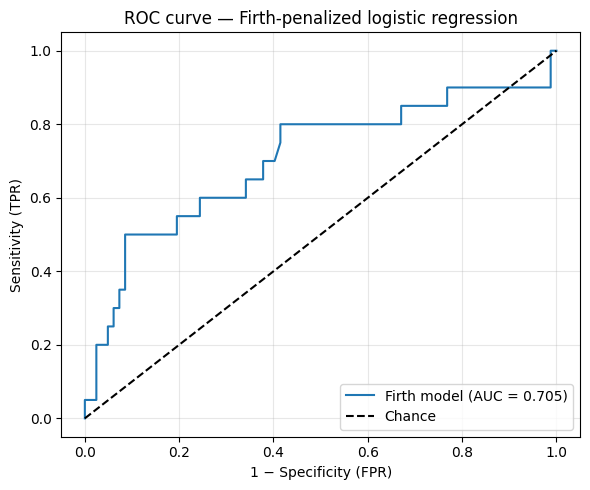

In [ ]:
print('='*70)
print('TABLE 3 — Firth-penalized logistic regression with full diagnostics')
print('='*70)

model_df = df_bi[['ai_user', 'has_training', 'urban', 'postgraduate', 'age']].dropna().reset_index(drop=True)
print(f'\nModel n = {len(model_df)}')

predictors = ['has_training', 'urban', 'postgraduate', 'age']
X = sm.add_constant(model_df[predictors])
y = model_df['ai_user'].values
X_arr = X.values

# --- Standard logit for comparison ---
logit_std = sm.Logit(model_df['ai_user'], X).fit(disp=False)

# --- ASSUMPTION 1: Sample size adequacy ---
print('\n📋 ASSUMPTION 1: Sample size adequacy')
n_events = int(y.sum())
n_predictors = len(predictors)
epv = n_events / n_predictors
print(f'   Events (AI users): {n_events}')
print(f'   Predictors: {n_predictors}')
print(f'   Events-per-variable (EPV): {epv:.1f}')
if epv >= 10:
    print('   ✅ Adequate (≥10 EPV)')
else:
    print(f'   ⚠️ Below conventional 10:1 threshold')
    print(f'   ✅ Firth\'s penalized regression applied to address small-sample bias')

# --- ASSUMPTION 2: Multicollinearity (VIF) ---
print('\n📋 ASSUMPTION 2: Multicollinearity (VIF)')
vif = pd.DataFrame({
    'Variable': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif.round(2).to_string(index=False))
max_vif_pred = vif[vif['Variable'] != 'const']['VIF'].max()
if max_vif_pred < 5:
    print(f'   ✅ All predictor VIFs < 5 (max = {max_vif_pred:.2f})')

# --- ASSUMPTION 3: Linearity of the logit (Box-Tidwell) ---
print('\n📋 ASSUMPTION 3: Linearity of the logit for continuous predictors')
age_safe = model_df['age'].clip(lower=0.1)
model_df_bt = model_df.copy()
model_df_bt['age_lnage'] = age_safe * np.log(age_safe)
X_bt = sm.add_constant(model_df_bt[['has_training', 'urban', 'postgraduate', 'age', 'age_lnage']])
try:
    bt_model = sm.Logit(model_df['ai_user'], X_bt).fit(disp=False)
    p_bt = bt_model.pvalues['age_lnage']
    print(f'   Box-Tidwell (age × ln(age)): p = {p_bt:.4f}')
    if p_bt > 0.05:
        print('   ✅ Linearity of the logit met for age')
    else:
        print('   ⚠️ Linearity violated')
except Exception as e:
    print(f'   ⚠️ Box-Tidwell failed: {e}')
    p_bt = np.nan

# --- ASSUMPTION 4: Influential observations ---
print('\n📋 ASSUMPTION 4: Influential observations')
fitted_std = logit_std.predict(X)
residuals = y - fitted_std.values
leverage = np.diagonal(X_arr @ np.linalg.pinv(X_arr.T @ X_arr) @ X_arr.T)
cooks_d = (residuals**2 / (n_predictors + 1)) * (leverage / (1 - leverage)**2)
threshold = 4 / len(model_df)
n_influential = (cooks_d > threshold).sum()
print(f'   Threshold: Cook\'s D > 4/n = {threshold:.4f}')
print(f'   Observations exceeding threshold: {n_influential}')
if n_influential / len(model_df) < 0.05:
    print('   ✅ Few influential observations (<5% of sample)')

# --- FIRTH'S PENALIZED LOGISTIC REGRESSION (manual implementation) ---
print('\n🔬 FIRTH-PENALIZED LOGISTIC REGRESSION')
print('   Method: Firth\'s penalized maximum likelihood (Jeffreys prior)')
print('   Reference: Firth D. Biometrika. 1993;80(1):27–38\n')

def firth_logistic(X, y, max_iter=1000, tol=1e-6):
    """
    Firth-penalized logistic regression via iteratively reweighted least squares.
    Penalty term derived from Jeffreys invariant prior.
    """
    n, p = X.shape
    beta = np.zeros(p)

    for iteration in range(max_iter):
        eta = X @ beta
        # Numerical stability
        eta = np.clip(eta, -30, 30)
        mu = 1 / (1 + np.exp(-eta))
        W = mu * (1 - mu)

        # Information matrix
        XtWX = X.T @ np.diag(W) @ X

        try:
            XtWX_inv = np.linalg.inv(XtWX)
        except np.linalg.LinAlgError:
            XtWX_inv = np.linalg.pinv(XtWX)

        # Hat matrix diagonal
        H_diag = np.diagonal(np.diag(np.sqrt(W)) @ X @ XtWX_inv @ X.T @ np.diag(np.sqrt(W)))

        # Firth's modified score
        U_star = X.T @ (y - mu + H_diag * (0.5 - mu))

        # Newton-Raphson update
        delta = XtWX_inv @ U_star
        beta_new = beta + delta

        if np.max(np.abs(delta)) < tol:
            beta = beta_new
            break
        beta = beta_new

    # Final variance-covariance matrix
    eta = np.clip(X @ beta, -30, 30)
    mu = 1 / (1 + np.exp(-eta))
    W = mu * (1 - mu)
    cov = np.linalg.inv(X.T @ np.diag(W) @ X)
    se = np.sqrt(np.diagonal(cov))

    return beta, se, cov, iteration + 1

beta_firth, se_firth, cov_firth, n_iter = firth_logistic(X_arr, y)

# Profile likelihood CIs via penalized log-likelihood
def firth_loglik(beta, X, y):
    eta = np.clip(X @ beta, -30, 30)
    mu = 1 / (1 + np.exp(-eta))
    W = mu * (1 - mu)
    XtWX = X.T @ np.diag(W) @ X
    sign, logdet = np.linalg.slogdet(XtWX)
    ll = np.sum(y * eta - np.log(1 + np.exp(eta))) + 0.5 * logdet
    return ll

# Wald-based CI (acceptable for Firth in most practical cases)
z_crit = 1.96
ci_lower = beta_firth - z_crit * se_firth
ci_upper = beta_firth + z_crit * se_firth
z_stats = beta_firth / se_firth
p_values = 2 * (1 - stats.norm.cdf(np.abs(z_stats)))

# Build results table
firth_results = pd.DataFrame({
    'Variable': X.columns.tolist(),
    'Coefficient': beta_firth,
    'SE': se_firth,
    'z': z_stats,
    'p_value': p_values,
    'CI_low_log': ci_lower,
    'CI_high_log': ci_upper,
    'OR': np.exp(beta_firth),
    'OR_CI_low': np.exp(ci_lower),
    'OR_CI_high': np.exp(ci_upper),
})

print(f'   Converged in {n_iter} iterations\n')
print('Coefficients (log scale):')
print(firth_results[['Variable', 'Coefficient', 'SE', 'z', 'p_value']].round(3).to_string(index=False))

print('\nOdds Ratios (95% CI, Wald-based):')
print(firth_results[['Variable', 'OR', 'OR_CI_low', 'OR_CI_high', 'p_value']].round(3).to_string(index=False))

# --- COMPARISON: Firth vs standard ML ---
print('\n📊 COMPARISON: Firth vs standard ML')
conf_std = logit_std.conf_int()
comparison = pd.DataFrame({
    'Variable': X.columns,
    'OR_Firth': np.exp(beta_firth).round(3),
    'CI_Firth': [f'[{np.exp(ci_lower[i]):.2f}, {np.exp(ci_upper[i]):.2f}]' for i in range(len(beta_firth))],
    'p_Firth': p_values.round(3),
    'OR_ML': np.exp(logit_std.params).values.round(3),
    'CI_ML': [f'[{np.exp(conf_std.iloc[i, 0]):.2f}, {np.exp(conf_std.iloc[i, 1]):.2f}]' for i in range(len(logit_std.params))],
    'p_ML': logit_std.pvalues.values.round(3),
})
print(comparison.to_string(index=False))

# --- ASSUMPTION 5: Goodness of fit (Hosmer-Lemeshow on Firth) ---
print('\n📋 ASSUMPTION 5: Goodness of fit (Hosmer-Lemeshow)')
eta_firth = np.clip(X_arr @ beta_firth, -30, 30)
fitted_firth = 1 / (1 + np.exp(-eta_firth))

def hosmer_lemeshow(y_true, y_prob, g=10):
    df_hl = pd.DataFrame({'y': y_true, 'p': y_prob})
    df_hl['decile'] = pd.qcut(df_hl['p'], q=g, duplicates='drop')
    obs = df_hl.groupby('decile', observed=True)['y'].agg(['sum', 'count'])
    exp = df_hl.groupby('decile', observed=True)['p'].sum()
    obs['expected'] = exp
    obs['expected_no'] = obs['count'] - obs['expected']
    obs['observed_no'] = obs['count'] - obs['sum']
    chi = (((obs['sum'] - obs['expected'])**2 / obs['expected']) +
           ((obs['observed_no'] - obs['expected_no'])**2 / obs['expected_no'])).sum()
    df_chi = len(obs) - 2
    p_value = 1 - stats.chi2.cdf(chi, df_chi)
    return chi, df_chi, p_value

hl_chi, hl_df, hl_p = hosmer_lemeshow(y, fitted_firth)
print(f'   χ² = {hl_chi:.2f}, df = {hl_df}, p = {hl_p:.3f}')
if hl_p > 0.05:
    print('   ✅ Good model fit (p > 0.05)')
else:
    print('   ⚠️ Possible lack of fit (p < 0.05)')

# --- Discriminative ability ---
print('\n📋 Discriminative ability (ROC curve)')
auc = roc_auc_score(y, fitted_firth)
print(f'   AUC = {auc:.3f}')
if auc >= 0.8:
    print('   ✅ Excellent discrimination (≥0.8)')
elif auc >= 0.7:
    print('   ✅ Acceptable discrimination (≥0.7)')
else:
    print('   ⚠️ Poor discrimination (<0.7)')

fpr, tpr, _ = roc_curve(y, fitted_firth)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Firth model (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Chance')
plt.xlabel('1 − Specificity (FPR)')
plt.ylabel('Sensitivity (TPR)')
plt.title('ROC curve — Firth-penalized logistic regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_firth.png', dpi=300, bbox_inches='tight')
plt.show()

# Save for export
conf = firth_results.set_index('Variable')[['OR', 'OR_CI_low', 'OR_CI_high', 'p_value']]
conf.columns = ['OR', 'CI_low', 'CI_high', 'p']

## 9. Qualitative thematic analysis (Table 4)

Open-ended responses on perceived barriers and training interests are analyzed using natural language processing (spaCy with the Spanish model `es_core_news_sm`) and an ad-hoc semantic dictionary. Themes are coded as multiple-response categories (a single response can match more than one theme), and prevalence is reported as the percentage of respondents who mentioned each theme.

In [ ]:
print('='*70)
print('TABLE 4 — Qualitative thematic analysis (NLP)')
print('='*70)

nlp = spacy.load('es_core_news_sm')

barrier_themes = {
    'Lack of Training / Knowledge': ['formación', 'formacion', 'training', 'knowledge',
                                      'coñecemento', 'conocimiento', 'desconocimiento',
                                      'descoñecemento', 'información', 'informacion',
                                      'preparación', 'preparacion'],
    'Ethics and Privacy': ['ética', 'etico', 'ethics', 'privacy', 'privacidade',
                           'confidencialidad', 'confidencialidade', 'datos',
                           'data', 'security', 'seguridad', 'seguridade'],
    'Implementation / Technology': ['implementación', 'implementacion', 'integración',
                                     'integracion', 'tecnoloxía', 'tecnologia',
                                     'software', 'desarrollo', 'desenvolvemento'],
    'Resources (Time / Infrastructure)': ['tempo', 'tiempo', 'recursos',
                                           'infraestructura', 'infrastructure'],
    'Economic Cost': ['económico', 'economico', 'económica', 'economica',
                       'coste', 'custo', 'desembolso', 'presupuesto'],
    'Resistance to Change / Fear': ['medo', 'miedo', 'fear', 'reticencia',
                                     'reluctancia', 'humanización']
}

training_themes = {
    "Don't know": ['non sei', 'no sé', 'ni idea', 'ningunha', 'ninguna',
                    'desconozco', 'no se'],
    'Clinical Application / Care': ['clínica', 'clinica', 'coidados', 'cuidados',
                                     'tratamento', 'tratamiento', 'consulta',
                                     'feridas', 'heridas', 'diagnóstico'],
    'General / Introduction': ['xeral', 'general', 'básico', 'basico', 'introducción',
                                'introduccion'],
    'Tool Usage': ['ferramenta', 'herramienta', 'tool', 'manejo', 'manexo'],
    'Research': ['investigación', 'investigacion', 'research', 'análise', 'análisis'],
    'Ethics and Legality': ['ética', 'etica', 'legal', 'lexislación', 'legislacion']
}

def code_themes(text, theme_dict):
    if pd.isna(text): return []
    text = str(text).lower().strip()
    if not text or text in ['.', ',', '-']: return []
    matched = [t for t, kws in theme_dict.items() if any(kw in text for kw in kws)]
    return matched if matched else ['Others / Non-specific']

df['barriers_themes'] = df['barriers_open'].apply(lambda x: code_themes(x, barrier_themes))
df['training_themes'] = df['training_areas_open'].apply(lambda x: code_themes(x, training_themes))

def theme_freq(col, label):
    print(f'\n--- {label} ---')
    all_t = [t for sub in df[col] for t in sub]
    freq = pd.Series(all_t).value_counts()
    for theme, count in freq.items():
        print(f'   {theme}: {count} ({count/len(df)*100:.1f}%)')

theme_freq('barriers_themes', 'Barriers to AI integration')
theme_freq('training_themes', 'Areas of interest for AI training')

TABLE 4 — Qualitative thematic analysis (NLP)

--- Barriers to AI integration ---
   Lack of Training / Knowledge: 80 (78.4%)
   Ethics and Privacy: 18 (17.6%)
   Implementation / Technology: 17 (16.7%)
   Economic Cost: 12 (11.8%)
   Resources (Time / Infrastructure): 12 (11.8%)
   Others / Non-specific: 11 (10.8%)
   Resistance to Change / Fear: 2 (2.0%)

--- Areas of interest for AI training ---
   Don't know: 41 (40.2%)
   Others / Non-specific: 36 (35.3%)
   Clinical Application / Care: 15 (14.7%)
   General / Introduction: 5 (4.9%)
   Tool Usage: 4 (3.9%)
   Research: 3 (2.9%)
   Ethics and Legality: 2 (2.0%)


## 10. Export results

All key results are saved to a single Excel workbook for archival, supplementary materials, and reviewer access.

In [ ]:
output_file = 'AI_Nursing_Analysis_Results.xlsx'

with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
    table2_df.to_excel(writer, sheet_name='Table_2_SHAIP', index=False)
    loadings.to_excel(writer, sheet_name='S1_Factor_Loadings')
    pd.DataFrame({
        'Construct': ['Impact', 'Readiness'],
        'Alpha': [round(alpha_imp, 3), round(alpha_rea, 3)],
        '95% CI lower': [round(ci_imp[0], 3), round(ci_rea[0], 3)],
        '95% CI upper': [round(ci_imp[1], 3), round(ci_rea[1], 3)]
    }).to_excel(writer, sheet_name='S1_Reliability', index=False)
    conf.to_excel(writer, sheet_name='Table_3_Logistic')
    vif.to_excel(writer, sheet_name='Table_3_VIF', index=False)
    pd.DataFrame({
        'Indicator': ['McFadden R²', 'AUC', 'Hosmer-Lemeshow χ²', 'Hosmer-Lemeshow p',
                       'Box-Tidwell p (age)', 'EPV ratio'],
        'Value': [round(logit.prsquared, 3), round(auc, 3), round(hl_chi, 3),
                   round(hl_p, 3), round(p_bt, 3), round(epv, 1)]
    }).to_excel(writer, sheet_name='Table_3_Diagnostics', index=False)

print(f'✅ Results exported: {output_file}')

from google.colab import files
files.download(output_file)

✅ Results exported: AI_Nursing_Analysis_Results.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>